# Plotting the measurements produced by QuPath

## SETTINGS

- In the `TSV_FILES` list, provide the absolute path of all the TSV for all time points. If you are on Windows, don't forget to replace the `\` by `/`.
- The `TIMEPOINT_LABELS` are just for display.
- The `COLORS` list contains the color used for each histogram. You can use [any color picker](https://htmlcolorcodes.com/color-picker/) if you need to change them.
- The `NB_BINS` is the number of bars in each histogram.

In [1]:

# Absolute paths to TSV files
TSV_FILES = [
    r"/home/clement/Desktop/translocation/translocation-00m/measurements.tsv",
    r"/home/clement/Desktop/translocation/translocation-20m/measurements.tsv",
    r"/home/clement/Desktop/translocation/translocation-40m/measurements.tsv",
]

# Labels displayed on the plots
TIMEPOINT_LABELS = [
    "0 min",
    "20 min",
    "40 min",
]

# One color per TSV
COLORS = [
    "#4C72B0",
    "#DD8452",
    "#55A868",
]

# Plot settings
NB_BINS = 40
FIGSIZE = (15, 4)

# Column names in the TSV files
IMAGE_COLUMN = "Image"
VALUE_COLUMN = "Translocation ratio"

## IMPORTS

- These are the modules required to plot our data.
- `pandas` is used to load and manipulate arrays on data (CSV, Excel, ...)
- `matplotlib` is used to draw basic plots. You can complete it with `seaborn` for more advanced plots.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## LOAD DATA

- In here, we load each CSV file in an independant dataframe.

In [3]:
dataframes = []

for tsv_path in TSV_FILES:

    df = pd.read_csv(
        tsv_path,
        sep="\t",
    )

    if VALUE_COLUMN not in df.columns:
        raise ValueError(
            f"Column '{VALUE_COLUMN}' not found in:\n{tsv_path}"
        )

    dataframes.append(df)

## DISTRIBUTION HISTOGRAMS

- `matplotlib` has a built-in function to generate histograms from arrays of data.

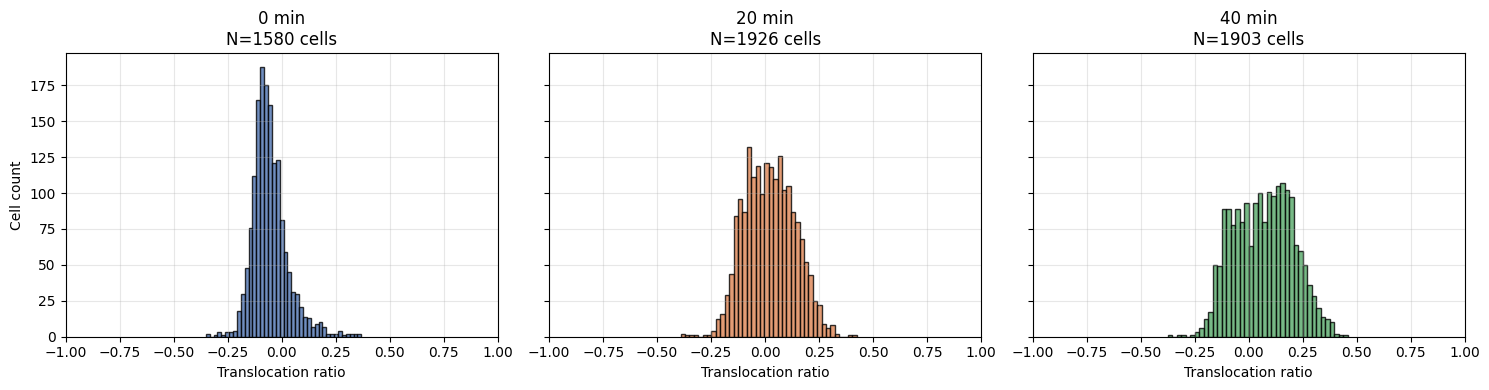

In [4]:
fig, axes = plt.subplots(
    1,
    len(dataframes),
    figsize=FIGSIZE,
    sharex=True,
    sharey=True,
)

if len(dataframes) == 1:
    axes = [axes]

for ax, df, label, color in zip(
    axes,
    dataframes,
    TIMEPOINT_LABELS,
    COLORS,
):

    values = df[VALUE_COLUMN].dropna()

    ax.hist(
        values,
        bins=NB_BINS,
        color=color,
        alpha=0.8,
        edgecolor="black",
    )

    ax.set_title(
        f"{label}\nN={len(values)} cells"
    )

    ax.set_xlim(-1, 1)
    ax.set_xlabel("Translocation ratio")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Cell count")

plt.tight_layout()
plt.show()

## SUMMARY STATISTICS

- If values are negative (min=-1), the signal is rather cytoplasmic.
- If values are close to 0, the signal is as intense in the nucleus as in the cytoplasm.
- If the values are positive (max=1), the signal is rather nuclear.

In [5]:
summary_rows = []

for label, df in zip(TIMEPOINT_LABELS, dataframes):

    values = df[VALUE_COLUMN].dropna()

    summary_rows.append(
        {
            "Time": label,
            "N cells": len(values),
            "Mean": values.mean(),
            "Std": values.std(),
            "Min": values.min(),
            "Q1 (25%)": values.quantile(0.25),
            "Median": values.median(),
            "Q3 (75%)": values.quantile(0.75),
            "Max": values.max(),
            "IQR": values.quantile(0.75) - values.quantile(0.25),
        }
    )

summary_df = pd.DataFrame(summary_rows)

# Optional formatting
display(
    summary_df.round(
        {
            "Mean": 3,
            "Std": 3,
            "Min": 3,
            "Q1 (25%)": 3,
            "Median": 3,
            "Q3 (75%)": 3,
            "Max": 3,
            "IQR": 3,
        }
    )
)


,Time,N cells,Mean,Std,Min,Q1 (25%),Median,Q3 (75%),Max,IQR
0,0 min,1580,-0.055,0.084,-0.351,-0.107,-0.067,-0.016,0.369,0.091
1,20 min,1926,0.020,0.115,-0.391,-0.069,0.017,0.103,0.424,0.172
2,40 min,1903,0.069,0.136,-0.374,-0.043,0.075,0.172,0.460,0.216
